# 08 — Predicting 2026 turnout


**Goal:** Forecast each municipality's 2026 turnout, test the model honestly against a baseline, and show which factors are associated with each municipality's risk.

**Reads:** `PROCESSED / "master.csv"` (made by `06_master`)
**Writes:** `PROCESSED / "predictions_2026.csv"`, `PROCESSED / "model_results.csv"`,
`MODELS / "turnout_model.joblib"`, charts in `FIGURES / "model_*.png"`

### Approach Overview

**2026 turnout = 2021 turnout + national swing + model adjustment for this municipality**

- **National swing:** The uniform change in turnout across all municipalities (e.g., the COVID drop in 2021). This is a scenario-driven input.
- **Model adjustment:** The municipality-specific adjustment, indicating whether a municipality is expected to perform better or worse than the national swing, based on its characteristics and province. This is learned by the model.

**Main model: Hierarchical (mixed-effects) regression** — Municipalities are grouped within provinces (team decision). Ridge regression and LightGBM are used for comparison.

The rationale for this split is that historical analysis (2016 → 2021) showed most prediction error stemmed from the national swing (e.g., COVID impact). Models performed similarly once the swing was known. This approach prioritizes transparent, factor-by-factor explainable models, acknowledging the national swing as the primary uncertainty for 2026.

## Setup

In [ ]:
import sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Thato20-M/democratic-funnel.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    REPO_DIR = Path("/content/democratic-funnel")
    url = REPO_URL
    try:                                    # private repo: token from Colab Secrets
        from google.colab import userdata
        url = REPO_URL.replace("https://", f"https://{userdata.get('GITHUB_TOKEN')}@")
    except Exception:
        print("No GITHUB_TOKEN in Colab Secrets - cloning will fail for the private repo")
    if REPO_DIR.exists():
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "-q"], check=True)
    else:
        subprocess.run(["git", "clone", "-q", url, str(REPO_DIR)], check=True)
else:
    REPO_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / "src" / "config.py").exists())

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print("Repo:", REPO_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo: /content/democratic-funnel


In [ ]:
from src import config
from src.config import RAW, INTERIM, PROCESSED, MODELS, FIGURES, SEED
from src.io_utils import read_any, clean_columns, inventory
from src.privacy import drop_personal

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings("ignore", category=FutureWarning)

config.make_dirs(); config.set_seed()
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
# house colours (same as 07_eda and the dashboard); no grey anywhere (team rule); 12pt minimum text
BLUE, AMBER, NAVY, CRIMSON, GREEN = "#2a78d6", "#eda100", "#1b2f5b", "#a3143a", "#2e7d4f"
LIGHT_BLUE, LIGHT_AMBER = "#9ec5f0", "#f6d58a"
plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12, "xtick.labelsize": 12,
                     "ytick.labelsize": 12, "legend.fontsize": 12, "legend.title_fontsize": 12})
PER_SD = "per typical difference between municipalities"   # = one standard deviation, in plain words
print(config.describe())

Environment: Colab
Repo root:   /content/democratic-funnel
Work root:   /content/drive/MyDrive/DIRISA_SDC


## 1. Load the master table

This dataset contains one row per municipality per election (2011, 2016, 2021, 2026), covering 213 municipalities. For 2026, only registration data is available, with votes to be forecast.

In [ ]:
master = pd.read_csv(PROCESSED / "master.csv")

counts = master.groupby("election")["muni_code"].nunique()
print(counts, "\n")
assert counts.to_dict() == {2011: 213, 2016: 213, 2021: 213, 2026: 213}, "master.csv should have 213 municipalities per election"
assert not master.duplicated(["election", "muni_code"]).any()

national = master.groupby("election")[["votes_cast", "registered"]].sum()
national["turnout"] = national["votes_cast"] / national["registered"]
print(national["turnout"].round(4))
assert national.loc[2016, "turnout"] != national.loc[2021, "turnout"], "2016 and 2021 are identical - re-run the 01 notebooks"

election
2011    213
2016    213
2021    213
2026    213
Name: muni_code, dtype: int64 

election
2011    0.5745
2016    0.5774
2021    0.4559
2026    0.0000
Name: turnout, dtype: float64


## 2. Feature Engineering

All features are designed to be known *before* the election being predicted:

| Feature | Description |
|---|---|
| `t_prev` | Turnout at the previous election |
| `r_prev_capped` | Registration rate at the previous election, capped at 1.05 (see note below) |
| `spatial_lag_prev` | Average turnout of neighboring municipalities at the *previous* election |
| `log_density` | Logarithm of population density (people per km²) |
| `metro` | Binary flag: 1 for metropolitan municipalities, 0 otherwise |

**Census Candidates:** Features derived from Census 2022, applied consistently across election years: `piped_water_rate`, `electricity_rate`, `refuse_removal_rate`, `higher_ed_rate`, and `youth_share` (young adults' share of adults). These are included in the model only if they pass the tests in Section 3b.

**Note on `spatial_lag_prev` vs. `spatial_lag_turnout`:** `spatial_lag_turnout` in the master table refers to neighbors' turnout in the *same* election. For 2026 forecasts, this information is unavailable. Therefore, `spatial_lag_prev` uses neighbors' turnout from the *previous* election, similar to how `t_prev` is used.

**Note on `r_prev_capped`:** A few small municipalities exhibit registration rates (`r_prev`) above 1.05, likely due to small Census sample sizes rather than actual registration. These values are capped at 1.05 to mitigate this artifact.

**Target variable:** `rel_change` = this municipality's change in turnout **minus** the average change across all municipalities in that election. This measures whether a municipality performed better or worse relative to the national trend.

In [ ]:
CORE = ["t_prev", "r_prev_capped", "spatial_lag_prev", "log_density", "metro"]
CANDIDATES = {"piped_water_rate": "piped water", "electricity_rate": "electricity",
              "refuse_removal_rate": "refuse removal", "higher_ed_rate": "higher education",
              "youth_share": "young adults' share of adults"}
FEATURES = CORE                                           # Census candidates are added in section 3b

df = master.sort_values(["muni_code", "election"]).copy()
df["spatial_lag_prev"] = df.groupby("muni_code")["spatial_lag_turnout"].shift(1)
df["r_prev_capped"]    = df["r_prev"].clip(upper=1.05)
df["log_density"]      = np.log(df["pop_density"])
df["metro"]            = (df["muni_category"] == "A").astype(int)
df["youth_share"]      = df["eligible_youth"] / df["eligible_adults"]

swing = df.groupby("election")["dt"].mean()          # average change per election = national swing
df["swing"] = df["election"].map(swing)
df["rel_change"] = df["dt"] - df["swing"]

print("Average change in turnout per election (national swing), in points:")
print((swing.dropna() * 100).round(2).to_string(), "\n")
print("Registration rate above 1.05 (capped):")
print(df.loc[df["r_prev"] > 1.05, ["election", "muni_code", "muni_name", "r_prev"]].to_string(index=False))

# same-year neighbours' turnout is not known for 2026, and 2011 rows are the crosswalked ones from 06_master
assert "spatial_lag_turnout" not in FEATURES and "covid_shock" not in FEATURES

missing = df.loc[df["election"] >= 2016, CORE + list(CANDIDATES)].isna().sum()
assert missing.sum() == 0, f"Missing feature values:\n{missing[missing > 0]}"

Average change in turnout per election (national swing), in points:
election
2016   -0.95
2021   -9.07 

Registration rate above 1.05 (capped):
 election muni_code  muni_name   r_prev
     2016     NC064 KAMIESBERG 1.104999
     2021     NC064 KAMIESBERG 1.168420
     2026     NC064 KAMIESBERG 1.192154
     2016     NC067    KHâI-MA 1.654952
     2021     NC067    KHâI-MA 1.817354
     2026     NC067    KHâI-MA 1.988154
     2021     NC074  KAREEBERG 1.073254
     2026     NC074  KAREEBERG 1.088273


## 3. Training and Testing Strategy

The model is evaluated using a time-based split to simulate real-world prediction:

| Dataset | Rows | Change Predicted |
|---|---|---|
| **Train** | election = 2016 | 2011 → 2016 |
| **Test** | election = 2021 | 2016 → 2021 |

All reported errors are in **turnout points** (1 point = 1 percentage point of turnout).

In [ ]:
train = df[df["election"] == 2016]
test  = df[df["election"] == 2021]
print(f"Train: {len(train)} municipalities (2011 -> 2016)   Test: {len(test)} municipalities (2016 -> 2021)")

def score(name, predicted_change):
    err = (test["dt"] - predicted_change) * 100
    return {"model": name, "MAE": np.abs(err).mean(), "RMSE": np.sqrt((err ** 2).mean())}

results = []

Train: 213 municipalities (2011 -> 2016)   Test: 213 municipalities (2016 -> 2021)


## 3b. Feature Selection Methodology

Given the aggregated nature of municipality-level data, direct causal inference is limited. This section describes the rigorous testing process for each candidate feature, ensuring only robust predictors are included. The selection process uses **only the training data** (2011 → 2016 change), keeping the 2021 test set unseen. A feature is considered to "hold up" if it passes all four criteria:

1.  **Target:** Predicts the change in turnout (`dt`).
2.  **Contextual Control:** Regression is performed for each factor, controlling for `log_density` and `province`. This addresses potential confounding, as well-serviced areas often correlate with urban density.
3.  **Bootstrap Confidence Intervals:** A 95% confidence interval for the effect is calculated via 1,000 bootstrapped resamples. A range that crosses zero indicates no statistically significant evidence of an effect.
4.  **Cross-Validation:** The feature's addition to the model's core features must reduce cross-validated error on the training set. Folds are defined by whole **districts** to maintain spatial integrity, ensuring neighboring municipalities are not split between training and validation sets.

After selection, each accepted feature's effect is also observed on the 2016 → 2021 test set, but this observation does not influence selection. Candidate features include Census service rates (piped water, electricity, refuse removal) and demographic indicators (higher education, youth share). Unemployment figures from Census 2022 were not used due to reliability concerns from Stats SA. Party results are intentionally excluded to maintain a focus on participation.

**Only features that pass all four tests are incorporated into the models.** Those that do not are reported and excluded.

**Terminology:** Descriptions consistently use "associated with" rather than "causes" to reflect the observational nature of the findings.

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ALPHAS = np.logspace(-2, 3, 40)


def ridge():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))


print("Testing:", ", ".join(CANDIDATES.values()))
N_BOOT = 1000
rng = np.random.default_rng(SEED)


def effect(d, col):
    """Change in turnout (points) per 1 SD of the factor, holding density and province constant."""
    z = (d[col] - d[col].mean()) / d[col].std()
    X = pd.concat([pd.Series(1.0, index=d.index), z, d["log_density"],
                   pd.get_dummies(d["province"], drop_first=True, dtype=float)], axis=1)
    return np.linalg.lstsq(X.to_numpy(float), d["dt"].to_numpy(float), rcond=None)[0][1] * 100


def boot(d, col):
    idx = rng.integers(0, len(d), size=(N_BOOT, len(d)))
    return np.quantile([effect(d.iloc[i], col) for i in idx], [0.025, 0.975])


from sklearn.model_selection import GroupKFold, cross_val_score

CV = GroupKFold(n_splits=5)


def cv_mae(cols):
    """Cross-validated error (points) on the training rows; folds are whole districts."""
    s = cross_val_score(ridge(), train[cols], train["rel_change"], groups=train["district_code"],
                        cv=CV, scoring="neg_mean_absolute_error")
    return -s.mean() * 100


core_cv = cv_mae(CORE)
rows = []
for col, label in CANDIDATES.items():
    row = {"column": col, "factor": label}
    for name, d_ in [("2011-2016", train), ("2016-2021", test)]:
        lo, hi = boot(d_, col)
        row |= {f"effect {name}": effect(d_, col), f"low {name}": lo, f"high {name}": hi}
    row["CV MAE change"] = cv_mae(CORE + [col]) - core_cv
    clear = row["low 2011-2016"] > 0 or row["high 2011-2016"] < 0
    row["holds up"] = bool(clear and row["CV MAE change"] < 0)                  # training rows only
    row["same way in 2016-2021"] = bool(np.sign(row["effect 2011-2016"]) == np.sign(row["effect 2016-2021"]))
    rows.append(row)

factor_tests = pd.DataFrame(rows)
factor_tests.to_csv(PROCESSED / "factor_tests.csv", index=False)
print(f"Core model, cross-validated on 2011 -> 2016: MAE {core_cv:.2f} points (negative change = the factor helps)")
print(factor_tests.drop(columns="column").round(2).to_string(index=False))

Testing: piped water, electricity, refuse removal, higher education, young adults' share of adults
Core model, cross-validated on 2011 -> 2016: MAE 2.03 points (negative change = the factor helps)
                       factor  effect 2011-2016  low 2011-2016  high 2011-2016  effect 2016-2021  low 2016-2021  high 2016-2021  CV MAE change  holds up  same way in 2016-2021
                  piped water              0.05          -0.36            0.44             -1.10          -1.53           -0.59           0.01     False                  False
                  electricity             -0.34          -0.71            0.07              0.25          -0.16            0.65          -0.02     False                  False
               refuse removal             -0.15          -0.68            0.35             -1.30          -1.85           -0.68           0.02     False                   True
             higher education              0.03          -0.40            0.44             -0.54   

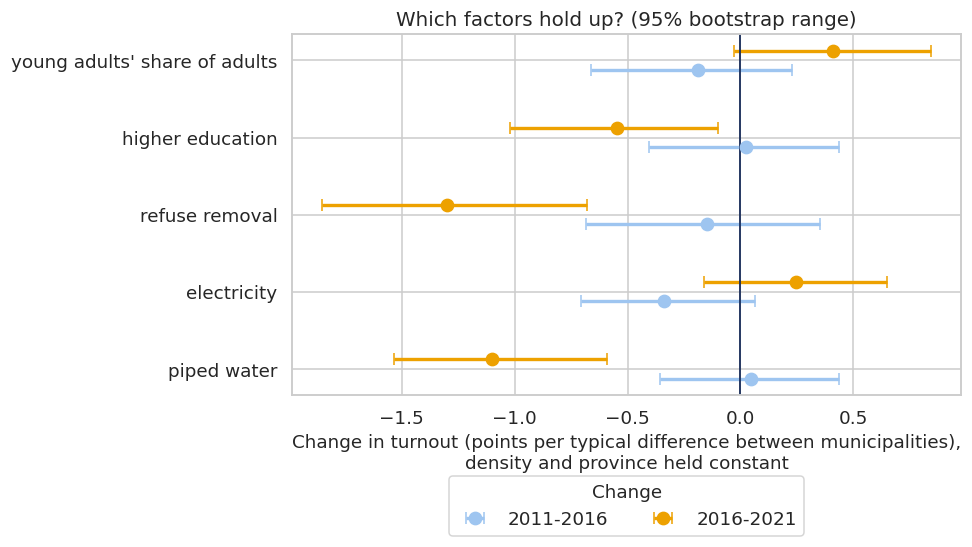

Features used by the models: ['t_prev', 'r_prev_capped', 'spatial_lag_prev', 'log_density', 'metro']
No factor holds up. We tested it: piped water, electricity, refuse removal, higher education, young adults' share of adults do not separate municipalities whose turnout fell from those where it held in both periods, once density and province are taken into account.
Only in 2016 -> 2021 (piped water, refuse removal, higher education): better-serviced municipalities fell more in 2021 only, not before. It points to COVID hitting urban-type places, not to services driving turnout.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 0.7 * len(factor_tests) + 1.8))
y = np.arange(len(factor_tests))
for k, (name, colr) in enumerate([("2011-2016", LIGHT_BLUE), ("2016-2021", AMBER)]):
    e = factor_tests[f"effect {name}"]
    ax.errorbar(e, y + (k - 0.5) * 0.25, fmt="o", ms=8, lw=2.2, color=colr, label=name, capsize=4,
                xerr=[e - factor_tests[f"low {name}"], factor_tests[f"high {name}"] - e])
ax.axvline(0, color=NAVY, lw=1.2)
ax.set_yticks(y, factor_tests["factor"])
ax.set(xlabel=f"Change in turnout (points {PER_SD}),\ndensity and province held constant",
       title="Which factors hold up? (95% bootstrap range)")
ax.legend(title="Change", loc="upper center", bbox_to_anchor=(0.5, -0.2), ncols=2)
plt.tight_layout(); fig.savefig(FIGURES / "model_factor_tests.png", dpi=200, bbox_inches="tight")
plt.show()

held = factor_tests.loc[factor_tests["holds up"], "factor"].tolist()
FEATURES = CORE + factor_tests.loc[factor_tests["holds up"], "column"].tolist()
print("Features used by the models:", FEATURES)
if held:
    print("Holds up (associated with the change in turnout, not proven causes):", ", ".join(held))
else:
    print("No factor holds up. We tested it: " + ", ".join(factor_tests["factor"]) +
          " do not separate municipalities whose turnout fell from those where it held in both periods, "
          "once density and province are taken into account.")
only_2021 = factor_tests[(factor_tests["high 2016-2021"] < 0) & (factor_tests["low 2011-2016"] <= 0)
                         & (factor_tests["high 2011-2016"] >= 0)]["factor"].tolist()
if only_2021:
    print(f"Only in 2016 -> 2021 ({', '.join(only_2021)}): better-serviced municipalities fell more in 2021 only, "
          "not before. It points to COVID hitting urban-type places, not to services driving turnout.")

**Reading the chart.** Blue: 2011 → 2016 (the training rows, used to choose). Amber: 2016 → 2021 (reported, not
used to choose). Piped water, refuse removal and higher education stay clearly below zero in 2016 → 2021, but cross
zero in 2011 → 2016, so they are **not stable** and are left out of the model.

**Wording for the slides:** *"Better-serviced municipalities fell more in 2021 only, not before. It points to COVID
hitting urban-type places, not to services driving turnout."* Not "services barely go with turnout".

## 4. Baselines

Three baseline models are established for comparison:

-   **No change:** Assumes 2021 turnout equals 2016 turnout. Represents the simplest forecast.
-   **Uniform swing:** Assumes 2021 turnout equals 2016 turnout plus the national swing. This is the primary baseline for model comparison, as all subsequent models also account for the national swing.
-   **Swing guessed from the past:** Similar to uniform swing, but uses the 2011 → 2016 swing as the national swing. This demonstrates the impact of misestimating the national swing, as occurred with COVID.

In [ ]:
results.append(score("Baseline: no change", 0.0))
results.append(score("Baseline: uniform swing", test["swing"]))
results.append(score("Baseline: swing guessed from 2011->2016", swing[2016]))
pd.DataFrame(results).round(2)

,model,MAE,RMSE
0,Baseline: no change,9.13,9.96
1,Baseline: uniform swing,3.25,4.11
2,Baseline: swing guessed from 2011->2016,8.23,9.10


## 5. Ridge Regression (Comparison Model)

Ridge regression is employed as a linear model with L2 regularization, which constrains coefficient magnitudes. This enhances stability, especially with smaller sample sizes (213 municipalities) and potentially correlated features (e.g., Census rates). The regularization strength (`alpha`) is determined through cross-validation on the training data. Features are standardized, making coefficients interpretable as the change in turnout points per one standard deviation increase in the feature.

An extended version of Ridge regression, including province indicators, is also tested to evaluate the impact of provincial grouping.

In [ ]:
# ridge() is defined in section 3b
ridge_test = ridge().fit(train[FEATURES], train["rel_change"])
pred_ridge = ridge_test.predict(test[FEATURES]) + test["swing"]
results.append(score("Ridge regression", pred_ridge))

prov_train = pd.get_dummies(train["province"], prefix="prov", dtype=int)
prov_test  = pd.get_dummies(test["province"], prefix="prov", dtype=int).reindex(columns=prov_train.columns, fill_value=0)
ridge_prov = ridge().fit(pd.concat([train[FEATURES], prov_train], axis=1), train["rel_change"])
pred_prov  = ridge_prov.predict(pd.concat([test[FEATURES], prov_test], axis=1)) + test["swing"]
results.append(score("Ridge + province (tests grouping)", pred_prov))

print("Penalty chosen (alpha):", round(ridge_test[-1].alpha_, 2))
pd.DataFrame(results).round(2)

Penalty chosen (alpha): 8.89


,model,MAE,RMSE
0,Baseline: no change,9.13,9.96
1,Baseline: uniform swing,3.25,4.11
2,Baseline: swing guessed from 2011->2016,8.23,9.10
3,Ridge regression,3.43,4.45
4,Ridge + province (tests grouping),3.52,4.50


## 6. Hierarchical (Mixed-Effects) Model (Main Model)

This model uses the same features as Ridge regression but incorporates a separate intercept for each **province**. This hierarchical structure allows for *partial pooling*, where provinces with less data are pulled towards the national average, balancing individual provincial effects with overall trends. Features are standardized, ensuring coefficients are interpreted similarly to those in Ridge regression.

In [ ]:
import statsmodels.formula.api as smf


class HierarchicalModel:
    """Mixed-effects regression: features as fixed effects, a random intercept per province."""

    def fit(self, X, y, groups):
        self.scaler_ = StandardScaler().fit(X)
        data = pd.DataFrame(self.scaler_.transform(X), columns=X.columns, index=X.index)
        data["y"], data["group"] = y.values, groups.values
        self.result_ = smf.mixedlm("y ~ " + " + ".join(X.columns), data, groups=data["group"]).fit(reml=True)
        self.coef_ = self.result_.fe_params[list(X.columns)].values
        self.group_effect_ = {g: eff.iloc[0] for g, eff in self.result_.random_effects.items()}
        return self

    def predict(self, X, groups):
        data = pd.DataFrame(self.scaler_.transform(X), columns=X.columns, index=X.index)
        return self.result_.predict(data).values + groups.map(self.group_effect_).fillna(0).values


hier_test = HierarchicalModel().fit(train[FEATURES], train["rel_change"], train["province"])
pred_hier = hier_test.predict(test[FEATURES], test["province"]) + test["swing"]
results.append(score("Hierarchical (mixed-effects)", pred_hier))

print("Province effects learned from 2011 -> 2016 (points):")
print(pd.Series(hier_test.group_effect_).mul(100).round(2).sort_values().to_string())
pd.DataFrame(results).round(2)

Province effects learned from 2011 -> 2016 (points):
Eastern Cape    -0.61
Western Cape    -0.25
Limpopo         -0.19
North West      -0.12
Mpumalanga      -0.05
Northern Cape   -0.03
Gauteng          0.27
Free State       0.43
KwaZulu-Natal    0.56


/tmp/ipykernel_1943/1145984696.py:11: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  self.result_ = smf.mixedlm("y ~ " + " + ".join(X.columns), data, groups=data["group"]).fit(reml=True)


,model,MAE,RMSE
0,Baseline: no change,9.13,9.96
1,Baseline: uniform swing,3.25,4.11
2,Baseline: swing guessed from 2011->2016,8.23,9.10
3,Ridge regression,3.43,4.45
4,Ridge + province (tests grouping),3.52,4.50
5,Hierarchical (mixed-effects),3.49,4.49


## 7. LightGBM (Comparison Model)

LightGBM, a gradient-boosting tree-based model, can capture non-linear relationships. Due to the relatively small dataset (approximately 200 municipalities per election), the model's complexity is kept low (shallow trees, more examples per leaf) to prevent overfitting. This step is conditional on LightGBM being installed.

In [ ]:
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=7, min_child_samples=15,
                             subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                             random_state=SEED, verbose=-1)
    lgbm.fit(train[FEATURES], train["rel_change"])
    results.append(score("LightGBM", lgbm.predict(test[FEATURES]) + test["swing"]))
except ImportError:
    print("lightgbm is not installed - skipped (pip install lightgbm)")

results_table = pd.DataFrame(results).round(2)
results_table

,model,MAE,RMSE
0,Baseline: no change,9.13,9.96
1,Baseline: uniform swing,3.25,4.11
2,Baseline: swing guessed from 2011->2016,8.23,9.10
3,Ridge regression,3.43,4.45
4,Ridge + province (tests grouping),3.52,4.50
5,Hierarchical (mixed-effects),3.49,4.49
6,LightGBM,3.53,4.58


## Model Selection

The **hierarchical model** was selected as the main model. The table summarizes its performance relative to baselines, Ridge, and LightGBM. The `MAIN_MODEL` variable can be set to "ridge" to switch to Ridge regression for forecasting.

In [ ]:
MAIN_MODEL = "hierarchical"          # team decision; "ridge" is the alternative
MAIN_NAME = {"hierarchical": "Hierarchical (mixed-effects)", "ridge": "Ridge regression"}[MAIN_MODEL]
pred_main = {"hierarchical": pred_hier, "ridge": pred_ridge}[MAIN_MODEL]

mae_of = results_table.set_index("model")["MAE"]
main_mae = mae_of[MAIN_NAME]
print(f"Main model: {MAIN_NAME}  (MAE {main_mae:.2f} turnout points)")
print(f"Compared with: Ridge {mae_of['Ridge regression']:.2f}, "
      f"uniform-swing baseline {mae_of['Baseline: uniform swing']:.2f}, "
      f"no-change baseline {mae_of['Baseline: no change']:.2f}")
if "LightGBM" in mae_of:
    print(f"LightGBM {mae_of['LightGBM']:.2f}")
if main_mae > mae_of["Baseline: uniform swing"]:
    print("Honest note: the model did not beat the uniform-swing baseline on 2016->2021. "
          "COVID changed which municipalities fell most, so the 2011->2016 pattern did not carry over.")

results_table.to_csv(PROCESSED / "model_results.csv", index=False)

Main model: Hierarchical (mixed-effects)  (MAE 3.49 turnout points)
Compared with: Ridge 3.43, uniform-swing baseline 3.25, no-change baseline 9.13
LightGBM 3.53
Honest note: the model did not beat the uniform-swing baseline on 2016->2021. COVID changed which municipalities fell most, so the 2011->2016 pattern did not carry over.


## Model Check: Out-of-Sample Performance and Baseline Comparison

**Test Setup:** The model is trained exclusively on the 2011 → 2016 change (the `train` set, corresponding to 2016 rows). Feature selection (Section 3b) also utilized only this training data. The 2016 → 2021 change is never used for training or selection.

**National Swing Integration:** Each test prediction incorporates the *actual* 2016 → 2021 national swing (the average change across all 213 municipalities, approximately −9 points). The model does not predict this swing; for 2026, the swing is defined by scenarios (Section 8). This design means predictions average correctly but the key question is: **does the model differentiate municipalities that experienced larger versus smaller turnout drops?**

**Performance Metrics (2021 test, in turnout points):**
-   **Baseline 1: No change** — Municipalities maintain their 2016 turnout.
-   **Baseline 2: National swing** — All municipalities change by the uniform national swing.
-   **Our model** — National swing plus the model's municipality-specific adjustment.

**Ranking Ability:** The correlation between predicted and actual turnout change *after removing the national swing* indicates how well the model ranks municipalities (1 = perfect order, 0 = no better than chance), accompanied by a 95% bootstrap confidence interval.

In [ ]:
swing_2021 = test["swing"].iloc[0]
check = pd.DataFrame([score("Baseline 1: no change", 0.0),
                      score("Baseline 2: every municipality moves by the national swing", test["swing"]),
                      score(f"Our model ({MAIN_NAME}: swing + adjustment)", pred_main)]).set_index("model")
print(f"National swing 2016 -> 2021 given to the model and to Baseline 2: {swing_2021 * 100:+.2f} points\n")
print(check.round(2).to_string(), "\n")

# ranking: predicted vs actual change once the national swing is removed
adj_pred, adj_actual = (pred_main - test["swing"]).to_numpy(), test["rel_change"].to_numpy()
rank_r = np.corrcoef(adj_pred, adj_actual)[0, 1]
rank_rho = pd.Series(adj_pred).rank().corr(pd.Series(adj_actual).rank())
idx = rng.integers(0, len(adj_pred), size=(N_BOOT, len(adj_pred)))
boot_r = [np.corrcoef(adj_pred[i], adj_actual[i])[0, 1] for i in idx]
r_lo, r_hi = np.quantile(boot_r, [0.025, 0.975])
print(f"Ranking after removing the swing: correlation {rank_r:.2f} (95% range {r_lo:.2f} to {r_hi:.2f}), "
      f"rank correlation {rank_rho:.2f}")

gain = check.iloc[1] - check.iloc[2]              # positive = the model is better than Baseline 2
beats = bool((gain > 0).all())
print(f"Model vs Baseline 2: MAE {gain['MAE']:+.2f}, RMSE {gain['RMSE']:+.2f} points (positive = model better)")
if beats:
    print("\nThe model beats Baseline 2: it adds information about which municipalities fall more or less "
          "than the national swing.")
else:
    print("\nHonest result: the model does not beat Baseline 2. The model captures the national swing; "
          "differences between municipalities are hard to predict.")
if r_hi < 0:
    print("The ranking correlation is below zero: in 2021 the municipalities the 2011->2016 pattern expected to do "
          "better tended to do worse. COVID reversed the usual pattern (denser, higher-turnout places fell most).")
elif r_lo <= 0:
    print("The ranking correlation's range includes zero: no evidence that the model orders municipalities correctly.")
check.assign(**{"ranking correlation": [np.nan, np.nan, rank_r]}).round(2).to_csv(PROCESSED / "model_check.csv")

National swing 2016 -> 2021 given to the model and to Baseline 2: -9.07 points

                                                               MAE  RMSE
model                                                                   
Baseline 1: no change                                         9.13  9.96
Baseline 2: every municipality moves by the national swing    3.25  4.11
Our model (Hierarchical (mixed-effects): swing + adjustment)  3.49  4.49 

Ranking after removing the swing: correlation -0.16 (95% range -0.30 to -0.01), rank correlation -0.10
Model vs Baseline 2: MAE -0.24, RMSE -0.38 points (positive = model better)

Honest result: the model does not beat Baseline 2. The model captures the national swing; differences between municipalities are hard to predict.
The ranking correlation is below zero: in 2021 the municipalities the 2011->2016 pattern expected to do better tended to do worse. COVID reversed the usual pattern (denser, higher-turnout places fell most).


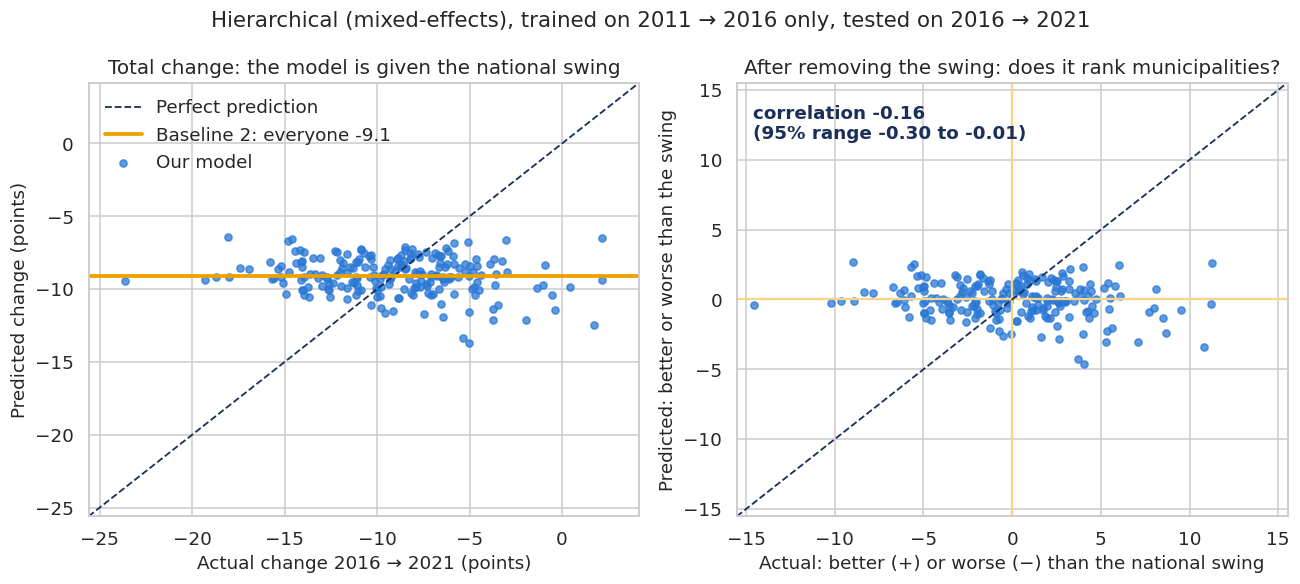

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.4))
act, pred = test["dt"] * 100, pred_main * 100
lims = [act.min() - 2, act.max() + 2]
ax1.plot(lims, lims, color=NAVY, lw=1.2, ls="--", label="Perfect prediction")
ax1.axhline(swing_2021 * 100, color=AMBER, lw=2.5, label=f"Baseline 2: everyone {swing_2021 * 100:+.1f}")
ax1.scatter(act, pred, s=22, color=BLUE, alpha=0.75, label="Our model")
ax1.set(xlabel="Actual change 2016 → 2021 (points)", ylabel="Predicted change (points)", xlim=lims, ylim=lims,
        title="Total change: the model is given the national swing")
ax1.legend(loc="upper left", frameon=False)

a2, p2 = adj_actual * 100, adj_pred * 100
m = max(np.abs(a2).max(), np.abs(p2).max()) + 1
ax2.axhline(0, color=LIGHT_AMBER, lw=1.5); ax2.axvline(0, color=LIGHT_AMBER, lw=1.5)
ax2.plot([-m, m], [-m, m], color=NAVY, lw=1.2, ls="--")
ax2.scatter(a2, p2, s=22, color=BLUE, alpha=0.75)
ax2.text(0.03, 0.95, f"correlation {rank_r:.2f}\n(95% range {r_lo:.2f} to {r_hi:.2f})", transform=ax2.transAxes,
         va="top", fontsize=12, color=NAVY, weight="bold")
ax2.set(xlabel="Actual: better (+) or worse (−) than the national swing", xlim=[-m, m], ylim=[-m, m],
        ylabel="Predicted: better or worse than the swing", title="After removing the swing: does it rank municipalities?")
fig.suptitle(f"{MAIN_NAME}, trained on 2011 → 2016 only, tested on 2016 → 2021", fontsize=14)
plt.tight_layout(); fig.savefig(FIGURES / "model_predicted_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Final Model and 2026 Forecast

The final model is trained on **all available historical data** (both 2011 → 2016 and 2016 → 2021 changes) to learn from a comprehensive history. It then predicts each municipality's turnout adjustment for the 2021 → 2026 period.

**2026 National Swing Scenarios:** The national swing for 2026 is defined by scenarios, reflecting the uncertainty post-COVID. Turnout may recover from the 2021 dip. Four scenarios are considered, three based on national turnout levels in 2016 and 2021, and one derived from the 2024 national election:

| Scenario | Description |
|---|---|
| `no_recovery` | Turnout remains at the 2021 level (swing = 0) |
| `half_recovery` | Turnout recovers half of the 2016 → 2021 drop |
| `full_recovery` | Turnout returns to the 2016 level |
| `npe2024_signal` | Derived from the 2024 national election results (see below) - **central scenario** |

**The 2024 Signal:** National elections typically have higher turnout than municipal elections. Historically, 2016 municipal turnout was a consistent share (73.48%, national ballot) of 2014 national turnout. Applying this same share to the 2024 national turnout (from `recent_signals.csv`) provides a municipal-equivalent turnout figure for 2024. The swing is then calculated as this figure minus 2021 turnout.

This 2024 signal serves as the central scenario, as it is based on observed post-COVID voter behavior, unlike the other three, which are assumptions. It suggests minimal recovery.

In [ ]:
final_train = df[df["election"].isin([2016, 2021])]
if MAIN_MODEL == "hierarchical":
    final_model = HierarchicalModel().fit(final_train[FEATURES], final_train["rel_change"], final_train["province"])
else:
    final_model = ridge().fit(final_train[FEATURES], final_train["rel_change"])


def adjustment(d):
    """How much better or worse than the national swing each municipality is expected to do."""
    if MAIN_MODEL == "hierarchical":
        return final_model.predict(d[FEATURES], d["province"])
    return final_model.predict(d[FEATURES])

drop = national.loc[2021, "turnout"] - national.loc[2016, "turnout"]      # negative: the COVID drop
SCENARIOS = {"no_recovery": 0.0, "half_recovery": -drop / 2, "full_recovery": -drop}

# 2024 national election signal (03_byelections_npe)
NPE_2014_TURNOUT = 0.7348                                                 # IEC 2014, national ballot
signals = pd.read_csv(INTERIM / "recent_signals.csv")
npe_2024 = signals["npe2024_votes_cast"].sum() / signals["npe2024_registered"].sum()
lge_per_npe = national.loc[2016, "turnout"] / NPE_2014_TURNOUT            # municipal turnout per national-election voter
SCENARIOS["npe2024_signal"] = npe_2024 * lge_per_npe - national.loc[2021, "turnout"]
print(f"2024 national turnout {npe_2024:.1%} x {lge_per_npe:.3f} = {npe_2024 * lge_per_npe:.1%} municipal-equivalent")
CENTRAL = "npe2024_signal"                                               # team decision, 26 Sep
print("National swing per scenario (points):", {k: round(v * 100, 2) for k, v in SCENARIOS.items()})

2024 national turnout 58.6% x 0.786 = 46.1% municipal-equivalent
National swing per scenario (points): {'no_recovery': 0.0, 'half_recovery': np.float64(6.08), 'full_recovery': np.float64(12.16), 'npe2024_signal': np.float64(0.48)}


/usr/local/lib/python3.13/dist-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_1943/1145984696.py:11: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  self.result_ = smf.mixedlm("y ~ " + " + ".join(X.columns), data, groups=data["group"]).fit(reml=True)
/usr/local/lib/python3.13/dist-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_1943/1145984696.py:11: ConvergenceWarning: Retrying MixedLM optimization with cg
  self.result_ = smf.mixedlm("y ~ " + " + ".join(X.columns), data, groups=data["group"]).fit(reml=True)
/usr/local/lib/python3.13/dist-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = s

In [ ]:
f26 = df[df["election"] == 2026].copy()
assert f26[FEATURES].notna().all().all(), "2026 rows are missing features"
f26["adjustment"] = adjustment(f26)

# Prediction interval: the spread of the main model's errors on the 2016 -> 2021 test (10th to 90th percentile)
resid = test["dt"] - pred_main
lo, hi = np.quantile(resid, [0.10, 0.90])

for name, s in SCENARIOS.items():
    f26[f"t_2026_{name}"] = (f26["t_prev"] + s + f26["adjustment"]).clip(0.05, 0.95)

f26["t_2026"]      = f26[f"t_2026_{CENTRAL}"]
f26["t_2026_low"]  = (f26["t_2026"] + lo).clip(0.05, 0.95)
f26["t_2026_high"] = (f26["t_2026"] + hi).clip(0.05, 0.95)
f26["p_2026"]      = f26["r"] * f26["t_2026"]          # real participation = registration rate x turnout
f26["r_above_1_05"] = (f26["r"] > 1.05).astype(int)     # Census undercount - see limitations

print(f"Interval: {lo * 100:+.1f} to {hi * 100:+.1f} points around each forecast (80% of 2021 errors fell in this range)")
print(f"National 2026 turnout, central scenario: "
      f"{(f26['t_2026'] * f26['registered']).sum() / f26['registered'].sum():.1%}")
f26[["muni_code", "muni_name", "t_prev", "adjustment", "t_2026_low", "t_2026", "t_2026_high", "p_2026"]].head()

Interval: -5.9 to +5.3 points around each forecast (80% of 2021 errors fell in this range)
National 2026 turnout, central scenario: 49.7%


,muni_code,muni_name,t_prev,adjustment,t_2026_low,t_2026,t_2026_high,p_2026
3,BUF,Buffalo City,0.450116,0.027137,0.423544,0.482088,0.535266,0.336561
7,CPT,City of Cape Town,0.466125,0.027776,0.440191,0.498735,0.551913,0.337474
11,EC101,Dr. Beyers Naude,0.470974,0.048955,0.466220,0.524763,0.577942,0.349131
15,EC102,Blue Crane Route,0.526389,0.045921,0.518601,0.577145,0.630323,0.321254
19,EC104,Makana,0.440180,0.045410,0.431880,0.490424,0.543602,0.339402


## 8b. The 2024 Rebound: Beyond Just COVID?

The `npe2024_turnout` feature is specific to 2026 and not present in training data (2011 → 2016, 2016 → 2021), thus it is treated as a **stated scenario** rather than a training feature.

Direct comparison of national and local turnout levels is misleading due to inherent differences. Instead, a municipality's **relative performance against the national figure** is analyzed:

**rebound = [(2024 national turnout here ÷ national 2024) − (2021 turnout here ÷ national 2021)]
− [(2019 national turnout here ÷ national 2019) − (2016 turnout here ÷ national 2016)]**

The second bracket represents the **pre-COVID typical gap** between national and local elections. This adjustment ensures that the `rebound` specifically measures changes attributable to COVID and post-COVID recovery, rather than baseline differences (e.g., rural vs. urban variations in national vs. local turnout).

-   **Positive `rebound`:** Indicates the municipality performed relatively better post-COVID, suggesting 2021 figures might have understated its typical turnout.
-   **Negative `rebound`:** Suggests the municipality is still lagging the national recovery.

The **COVID recovery** scenario adjusts each municipality's forecast by its calculated `rebound` (converted to turnout points at the national 2026 level). Both the model's primary forecast and this COVID recovery adjusted forecast are reported.

In [ ]:
sig_cols = [c for c in ["npe2024_turnout", "npe2019_turnout"] if c in signals.columns]
f26 = f26.drop(columns=sig_cols, errors="ignore").merge(signals[["muni_code"] + sig_cols], on="muni_code", how="left")
assert f26["npe2024_turnout"].notna().all(), "municipalities without 2024 turnout"

after_covid = f26["npe2024_turnout"] / npe_2024 - f26["t_prev"] / national.loc[2021, "turnout"]
if "npe2019_turnout" in f26 and f26["npe2019_turnout"].notna().all():
    npe_2019 = signals["npe2019_votes_cast"].sum() / signals["npe2019_registered"].sum()
    t_2016 = f26["muni_code"].map(df[df["election"] == 2016].set_index("muni_code")["t"])
    usual_gap = f26["npe2019_turnout"] / npe_2019 - t_2016 / national.loc[2016, "turnout"]
    f26["rebound"] = after_covid - usual_gap
    print(f"Pre-COVID baseline: 2019 national election "
          f"(usual gap correlates {usual_gap.corr(after_covid):.2f} with the raw 2024 rebound)")
else:
    f26["rebound"] = after_covid
    print("WARNING: no pre-COVID baseline in recent_signals.csv (see 03) - the rebound includes the usual gap")

nat_2026 = (f26["t_2026"] * f26["registered"]).sum() / f26["registered"].sum()
f26["t_2026_covid_recovery"] = (f26["t_2026"] + f26["rebound"] * nat_2026).clip(0.05, 0.95)
f26["covid_status"] = np.where(f26["rebound"] > 0, "recovered after COVID", "still falling")

nat_rec = (f26["t_2026_covid_recovery"] * f26["registered"]).sum() / f26["registered"].sum()
print(f"National 2026 turnout: model {nat_2026:.1%}, COVID recovery scenario {nat_rec:.1%}")
print(f26["covid_status"].value_counts().to_string())
print("\nRebound, in % of the national figure:")
print((f26["rebound"] * 100).describe().round(1).to_string())

Pre-COVID baseline: 2019 national election (usual gap correlates 0.64 with the raw 2024 rebound)
National 2026 turnout: model 49.7%, COVID recovery scenario 49.7%
covid_status
still falling            147
recovered after COVID     66

Rebound, in % of the national figure:
count    213.0
mean      -5.2
std        9.7
min      -36.0
25%      -11.5
50%       -5.1
75%        1.8
max       32.5


### Regional Impact of COVID: Urban vs. Rural Turnout Dynamics

The analysis of rebound by population density reveals differing impacts of COVID on turnout.

In 2021, the densest quartile of municipalities experienced a roughly 12-point turnout drop, compared to about 8 points elsewhere. The `rebound` metric already accounts for each municipality's **normal** national-versus-local election pattern (2016 → 2019). Therefore, a `rebound` value of **0 signifies a return to its normal pattern**, while negative values indicate continued underperformance.

-   If dense municipalities show a `rebound` near 0, their 2021 drop was likely a **COVID blip**, and they have since normalized.
-   If rural municipalities exhibit significantly negative `rebound` values, their turnout decline is **real and ongoing**, extending beyond the immediate COVID impact.

It is important to note that no group shows a rebound significantly above its normal pattern; therefore, statements like "the densest bounced back most" would be inaccurate.

               municipalities  mean_rebound  share_recovered
density_group                                               
Least dense                54         -10.7             19.0
2nd quarter                53          -4.5             32.0
3rd quarter                53          -5.3             25.0
Densest                    53          -0.2             49.0


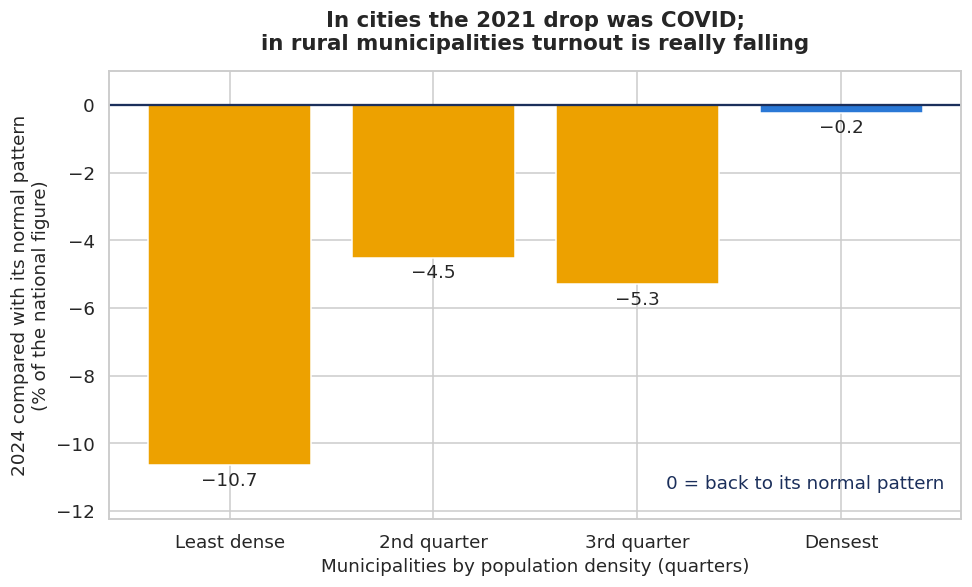

Densest quarter: -0.2% against its normal pattern; least dense quarter: -10.7%.
In cities the 2021 drop was COVID (back to normal in 2024); in rural municipalities turnout is really falling (still well below their normal pattern).


In [ ]:
DENSITY_GROUPS = ["Least dense", "2nd quarter", "3rd quarter", "Densest"]
f26["density_group"] = pd.qcut(f26["pop_density"], 4, labels=DENSITY_GROUPS)
by_density = f26.groupby("density_group", observed=True).agg(
    municipalities=("muni_code", "size"),
    mean_rebound=("rebound", "mean"),
    share_recovered=("rebound", lambda s: (s > 0).mean()))
print(by_density.assign(mean_rebound=lambda t: (t["mean_rebound"] * 100).round(1),
                        share_recovered=lambda t: (t["share_recovered"] * 100).round()).to_string())

fig, ax = plt.subplots(figsize=(9, 5.5))
vals = by_density["mean_rebound"] * 100
bars = ax.bar(DENSITY_GROUPS, vals, color=[AMBER, AMBER, AMBER, BLUE])
ax.bar_label(bars, labels=[f"{v:+.1f}".replace("-", "−") for v in vals], padding=4, fontsize=12)
ax.axhline(0, color=NAVY, lw=1.5)

# label for the zero line: bottom-right corner, where the chart is empty
ax.text(0.98, 0.06, "0 = back to its normal pattern", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=12, color=NAVY)

ax.set_ylim(vals.min() * 1.15, 1)            # a little room for the value labels
ax.set(ylabel="2024 compared with its normal pattern\n(% of the national figure)",
       xlabel="Municipalities by population density (quarters)")
ax.set_title("In cities the 2021 drop was COVID;\nin rural municipalities turnout is really falling",
             pad=14, fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES / "model_rebound_by_density.png", dpi=200, bbox_inches="tight")
plt.show()

densest, least = by_density.loc["Densest", "mean_rebound"] * 100, by_density.loc["Least dense", "mean_rebound"] * 100
print(f"Densest quarter: {densest:+.1f}% against its normal pattern; least dense quarter: {least:+.1f}%.")
if abs(densest) < 2 and least < -5:
    print("In cities the 2021 drop was COVID (back to normal in 2024); in rural municipalities turnout is really "
          "falling (still well below their normal pattern).")

## 9. Feature Contributions to Municipal Turnout Adjustments

Both Ridge and the hierarchical model are linear, allowing for decomposition of each municipality's turnout adjustment into individual feature contributions. This contribution is calculated as (coefficient × standardized feature value), plus the province's effect in the hierarchical model. These contributions are indicators of factors **associated with** turnout changes, not direct causal links, as municipality-level patterns may not reflect individual voter behavior.

                       effect   low  high
turnout last election   -1.38 -1.97 -0.91
population density      -1.27 -1.66 -0.87
neighbours' turnout     -0.79 -1.41 -0.04
registration rate       -0.12 -0.53  0.22
metro                    0.09 -0.11  0.29


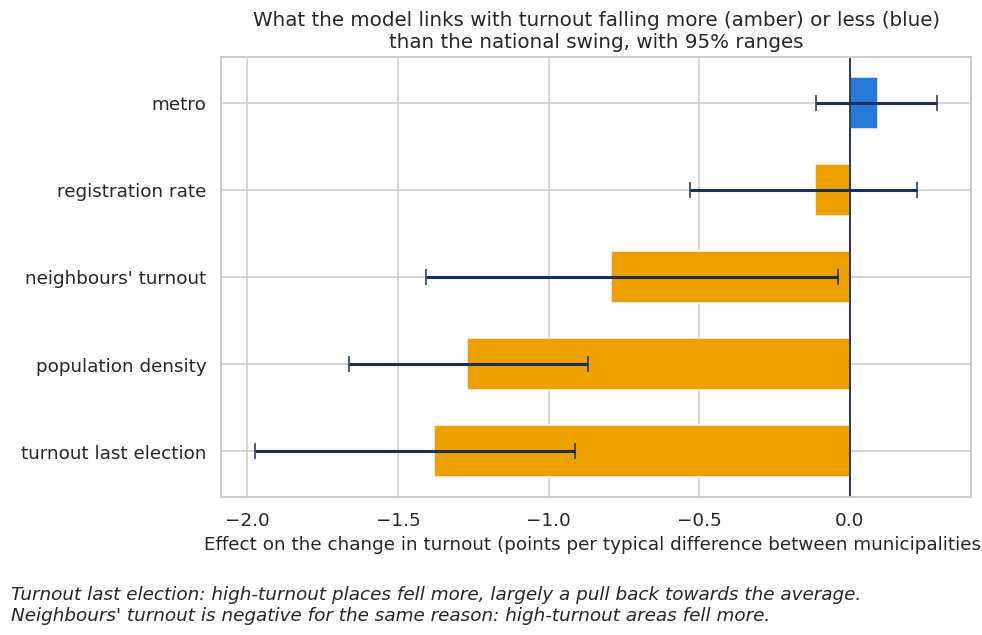

,muni_code,muni_name,main_factor_down,main_factor_up
0,BUF,Buffalo City,population density,turnout last election
1,CPT,City of Cape Town,population density,turnout last election
2,EC101,Dr. Beyers Naude,metro,turnout last election
3,EC102,Blue Crane Route,metro,neighbours' turnout
4,EC104,Makana,metro,turnout last election


In [ ]:
if MAIN_MODEL == "hierarchical":
    scaler, coefs = final_model.scaler_, final_model.coef_
    f26["province_effect"] = f26["province"].map(final_model.group_effect_)
else:
    scaler, coefs = final_model[0], final_model[-1].coef_
LABELS = {"t_prev": "turnout last election", "r_prev_capped": "registration rate",
          "spatial_lag_prev": "neighbours' turnout", "log_density": "population density", "metro": "metro",
          "piped_water_rate": "piped water", "electricity_rate": "electricity",
          "refuse_removal_rate": "refuse removal", "higher_ed_rate": "higher education",
          "youth_share": "young adults' share", "services": "services", "province": "province"}
coef = pd.Series(coefs, index=FEATURES)

# 95% ranges: refit the final model on municipalities resampled with replacement (both of a municipality's rows
# stay together), the same idea as the bootstrap in section 3b
N_BOOT_COEF = 300
codes = final_train["muni_code"].unique()
by_code = {c: g for c, g in final_train.groupby("muni_code")}
boot_coefs = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for _ in range(N_BOOT_COEF):
        b = pd.concat([by_code[c] for c in rng.choice(codes, len(codes))], ignore_index=True)
        if MAIN_MODEL == "hierarchical":
            boot_coefs.append(HierarchicalModel().fit(b[FEATURES], b["rel_change"], b["province"]).coef_)
        else:
            boot_coefs.append(ridge().fit(b[FEATURES], b["rel_change"])[-1].coef_)
ci = pd.DataFrame(np.quantile(boot_coefs, [0.025, 0.975], axis=0).T, index=FEATURES, columns=["low", "high"])
effects = pd.concat([coef.rename("effect"), ci], axis=1).mul(100).rename(index=LABELS).sort_values("effect")
print(effects.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 0.7 * len(effects) + 1.8))
y = np.arange(len(effects))
ax.barh(y, effects["effect"], color=np.where(effects["effect"] < 0, AMBER, BLUE), height=0.6)
ax.errorbar(effects["effect"], y, xerr=[effects["effect"] - effects["low"], effects["high"] - effects["effect"]],
            fmt="none", ecolor=NAVY, elinewidth=2, capsize=5)
ax.axvline(0, color=NAVY, lw=1.2)
ax.set_yticks(y, effects.index)
ax.set(xlabel=f"Effect on the change in turnout (points {PER_SD})", ylabel="",
       title="What the model links with turnout falling more (amber) or less (blue)\n"
             "than the national swing, with 95% ranges")
fig.text(0.01, -0.02, "Turnout last election: high-turnout places fell more, largely a pull back towards the "
         "average.\nNeighbours' turnout is negative for the same reason: high-turnout areas fell more.",
         fontsize=12, style="italic", va="top")
plt.tight_layout(); fig.savefig(FIGURES / "model_ridge_coefficients.png", dpi=200, bbox_inches="tight")
plt.show()

# each feature's contribution = coefficient x (value - average) / SD; with the intercept (and the province
# effect in the hierarchical model) they add up exactly to the municipality's adjustment
contrib = pd.DataFrame(scaler.transform(f26[FEATURES]) * coefs, columns=FEATURES, index=f26.index)

# water, electricity and refuse move together (water and refuse correlate at 0.78): explain them as one group
SERVICES = [c for c in ["piped_water_rate", "electricity_rate", "refuse_removal_rate"] if c in FEATURES]
if len(SERVICES) > 1:
    contrib["services"] = contrib[SERVICES].sum(axis=1)
    contrib = contrib.drop(columns=SERVICES)

bars = contrib.rename(columns=LABELS)
if MAIN_MODEL == "hierarchical":
    bars["province"] = f26["province_effect"]
for c in bars:
    f26[f"contrib: {c}"] = bars[c]                        # saved for the dashboard's bars
f26["main_factor_down"] = contrib.idxmin(axis=1).where(contrib.min(axis=1) < 0).map(LABELS)
f26["main_factor_up"]   = contrib.idxmax(axis=1).where(contrib.max(axis=1) > 0).map(LABELS)
f26[["muni_code", "muni_name", "main_factor_down", "main_factor_up"]].head()

**Interpreting the Effects Chart:**

-   **Turnout last election** shows a negative effect, indicating that municipalities with higher turnout in the previous election experienced larger relative declines. This largely reflects **regression to the mean**, where unusually high or low turnout levels tend to normalize over time.
-   **Neighbours' turnout** also exhibits a negative effect. This does **not** contradict the principle that "neighbours vote alike" (as explored in `07_eda`, which focuses on turnout *levels*). Instead, this chart analyzes *change* in turnout, and high-turnout areas collectively experienced greater declines. In explanations, this nuance should be clarified or the feature may be omitted.
-   Bars whose 95% confidence interval crosses zero do not show a statistically significant effect.
-   **Important Consideration:** As noted in the model check (Section 7), the model did not outperform the national-swing baseline on the 2021 test set. This implies that while these effects describe past associations, they do not definitively rank municipalities for 2026. The model effectively captures the national swing, but municipality-specific differences remain challenging to predict.

## 10. Worse Than Expected Performance

This section identifies municipalities where the actual 2021 turnout drop significantly exceeded the model's prediction. These "unexplained" declines suggest local factors not captured by the current model, warranting further investigation.

In [ ]:
test_resid = (test["dt"] - pred_main).rename("unexplained")
worst = test_resid.nsmallest(15)
flag = df.loc[worst.index, ["muni_code", "muni_name", "province"]].assign(unexplained_points=(worst * 100).round(1))
print("Largest unexplained drops, 2016 -> 2021:")
print(flag.to_string(index=False))

f26["worse_than_expected_2021"] = f26["muni_code"].isin(flag["muni_code"]).astype(int)

Largest unexplained drops, 2016 -> 2021:
muni_code            muni_name      province  unexplained_points
   KZN226         Mkhambathini KwaZulu-Natal               -14.1
      ETH            eThekwini KwaZulu-Natal               -11.6
   KZN225             Msunduzi KwaZulu-Natal                -9.9
    MP326     City of Mbombela    Mpumalanga                -9.5
      CPT    City of Cape Town  Western Cape                -8.9
      NMA   Nelson Mandela Bay  Eastern Cape                -8.8
    MP302           Msukaligwa    Mpumalanga                -8.3
      EKU           Ekurhuleni       Gauteng                -8.1
      JHB City of Johannesburg       Gauteng                -8.1
   KZN282           uMhlathuze KwaZulu-Natal                -7.6
      TSH      City of Tshwane       Gauteng                -7.0
      MAN             Mangaung    Free State                -6.9
    WC031      Theewaterskloof  Western Cape                -6.8
   KZN291              Mandeni KwaZulu-Natal     

## 11. Model and Prediction Saving

The final model components and the 2026 predictions are saved for future use and analysis, particularly for dashboard integration. The model is stored using `joblib`, while the predictions are saved as a CSV file.

In [ ]:
import joblib

# Save plain parts (not the notebook's own class), so the dashboard can load the file without this notebook
if MAIN_MODEL == "hierarchical":
    saved_model = {"scaler": final_model.scaler_, "statsmodels_result": final_model.result_,
                   "province_effect": final_model.group_effect_}
else:
    saved_model = final_model

joblib.dump({"model": saved_model, "main_model": MAIN_MODEL, "features": FEATURES, "scenarios": SCENARIOS, "central": CENTRAL,
             "interval": (lo, hi)}, MODELS / "turnout_model.joblib")

out = f26[["muni_code", "muni_name", "province", "muni_category", "registered", "eligible_adults", "r",
           "t_prev", "adjustment",
           "t_2026_no_recovery", "t_2026_half_recovery", "t_2026_full_recovery", "t_2026_npe2024_signal",
           "t_2026_low", "t_2026", "t_2026_high", "p_2026",
           "npe2024_turnout", "rebound", "t_2026_covid_recovery", "covid_status",
           "main_factor_down", "main_factor_up", "worse_than_expected_2021", "r_above_1_05"]
          + [c for c in f26.columns if c.startswith("contrib: ")]] \
    .rename(columns={"t_prev": "t_2021", "r": "r_2026", "registered": "registered_2026"}) \
    .sort_values("t_2026")

out.to_csv(PROCESSED / "predictions_2026.csv", index=False)
print(f"Saved {out.shape} to {PROCESSED / 'predictions_2026.csv'}")
out.head(10)

Saved (213, 31) to /content/drive/MyDrive/DIRISA_SDC/data/processed/predictions_2026.csv


,muni_code,muni_name,province,muni_category,registered_2026,eligible_adults,r_2026,t_2021,adjustment,t_2026_no_recovery,t_2026_half_recovery,t_2026_full_recovery,t_2026_npe2024_signal,t_2026_low,t_2026,t_2026_high,p_2026,npe2024_turnout,rebound,t_2026_covid_recovery,covid_status,main_factor_down,main_factor_up,worse_than_expected_2021,r_above_1_05,contrib: turnout last election,contrib: registration rate,contrib: neighbours' turnout,contrib: population density,contrib: metro,contrib: province
172,NW373,Rustenburg,North West,B,324493.0,3.587769e+05,0.904442,0.360087,0.044744,0.404831,0.465622,0.526413,0.409665,0.351121,0.409665,0.462843,0.370518,0.451315,-0.053816,0.382907,still falling,population density,turnout last election,1,0,0.053584,-0.001249,0.023478,-0.012455,-0.000185,-0.015589
177,NW383,Mafikeng,North West,B,150215.0,2.216377e+05,0.677750,0.375567,0.047416,0.422982,0.483774,0.544565,0.427817,0.369273,0.427817,0.480995,0.289953,0.512339,0.018634,0.437082,recovered after COVID,population density,turnout last election,0,0,0.049990,0.000697,0.023412,-0.008068,-0.000185,-0.015589
134,MP312,Emalahleni,Mpumalanga,B,219576.0,2.884349e+05,0.761267,0.393220,0.037125,0.430345,0.491137,0.551928,0.435180,0.376636,0.435180,0.488358,0.331288,0.589179,-0.040700,0.414944,still falling,population density,turnout last election,0,0,0.045891,0.000209,0.024070,-0.012613,-0.000185,-0.017405
132,MP307,Govan Mbeki,Mpumalanga,B,155046.0,2.118702e+05,0.731797,0.399112,0.036783,0.435896,0.496687,0.557478,0.440730,0.382187,0.440730,0.493908,0.322525,0.597436,0.011945,0.446669,recovered after COVID,population density,turnout last election,0,0,0.044523,0.000038,0.022030,-0.009377,-0.000185,-0.017405
28,EC157,King Sabata Dalindyebo,Eastern Cape,B,249284.0,2.876430e+05,0.866644,0.393536,0.049539,0.443075,0.503866,0.564657,0.447909,0.389366,0.447909,0.501088,0.388178,0.427069,-0.169137,0.363814,still falling,population density,turnout last election,0,0,0.045818,-0.000450,0.021384,-0.011638,-0.000185,-0.002548
137,MP315,Thembisile Hani,Mpumalanga,B,168944.0,2.789593e+05,0.605622,0.407284,0.037318,0.444603,0.505394,0.566185,0.449437,0.390894,0.449437,0.502615,0.272189,0.568820,0.087228,0.492807,recovered after COVID,population density,turnout last election,0,0,0.042626,0.001184,0.027211,-0.013271,-0.000185,-0.017405
142,MP326,City of Mbombela,Mpumalanga,B,362699.0,5.279538e+05,0.686990,0.409341,0.035703,0.445044,0.505836,0.566627,0.449879,0.391335,0.449879,0.503057,0.309062,0.600085,0.077605,0.488465,recovered after COVID,population density,turnout last election,1,0,0.042148,0.000628,0.022980,-0.009621,-0.000185,-0.017405
171,NW372,Madibeng,North West,B,254448.0,3.226535e+05,0.788611,0.408117,0.039748,0.447864,0.508656,0.569447,0.452699,0.394155,0.452699,0.505877,0.357003,0.529890,-0.024997,0.440270,still falling,population density,turnout last election,0,0,0.042432,-0.000193,0.026874,-0.010750,-0.000185,-0.015589
109,LIM343,Thulamela,Limpopo,B,261071.0,3.466520e+05,0.753121,0.407898,0.042051,0.449949,0.510740,0.571532,0.454784,0.396240,0.454784,0.507962,0.342507,0.513788,-0.106132,0.402014,still falling,population density,turnout last election,0,0,0.042483,0.000086,0.020655,-0.014184,-0.000185,-0.003963
59,JHB,City of Johannesburg,Gauteng,A,2417371.0,3.065793e+06,0.788498,0.420540,0.030754,0.451294,0.512085,0.572877,0.456129,0.397585,0.456129,0.509307,0.359656,0.621175,0.048683,0.480334,recovered after COVID,population density,turnout last election,1,0,0.039548,-0.000508,0.021014,-0.035299,0.004746,0.004094


## Summary of Key Findings

-   The model predicts the **change** in turnout, rigorously tested on later election data (2016 → 2021) rather than random splits.
-   **National trends dominate turnout changes:** The COVID-induced national turnout drop significantly impacted all municipalities. Accounting for the national swing reduces prediction error substantially (from ~9 points to ~3 points), a level not achievable by any single model alone.
-   **Model Performance (2016 → 2021 out-of-sample test):** The model, trained solely on 2011 → 2016 data and given the actual national swing for 2021, did **not** outperform Baseline 2 (uniform national swing for all municipalities). The correlation in ranking municipalities (after removing the swing) was slightly negative. This indicates that **while the model captures the national swing, municipality-specific differences were difficult to predict** in this period. The funnel analysis, municipality grouping, and priority list remain valid independently of the model's predictive ranking.
-   The primary model is a **hierarchical (mixed-effects) regression**, grouping municipalities by province. Ridge and LightGBM were tested for comparison, showing comparable performance when the national swing is known.
-   **2026 Forecast Scenarios:** Given the significant uncertainty of the national swing, the 2026 forecast is presented using multiple scenarios. The central scenario, derived from the 2024 national election results, suggests minimal recovery from the 2021 COVID drop. Other scenarios (no, half, full recovery) are also provided.
-   **Impact of COVID:** Analysis of the `rebound` metric (comparing 2024 national turnout to 2021 local turnout, adjusted for normal patterns) reveals that **in urban areas, the 2021 turnout drop appears to be a COVID-related anomaly (returning to normal in 2024), while in rural municipalities, turnout decline is more persistent** (remaining about 10% below their normal patterns).
-   **Feature Associations:** Individual Census factors were rigorously tested. None passed all tests to be included as robust predictors. The finding that **better-serviced municipalities experienced greater turnout declines in 2021 (but not before) suggests a COVID impact on urbanized areas rather than services driving turnout.**
-   **Effects Chart Interpretation:** Negative effects for "turnout last election" and "neighbours' turnout" indicate that municipalities with higher historical turnout experienced larger relative declines, primarily due to regression to the mean.
-   **Limitations:** The model is constrained by a small sample size (213 municipalities, two historical changes). The separation of COVID impact from longer-term turnout decline is challenging. The absence of reliable Census 2022 employment and income data limits the model's ability to account for economic hardship. The findings represent associations, not proven causal relationships. Some small municipalities exhibit registration rates above 1.0, likely due to Census sampling issues.